In [1]:
# End-to-End Machine Learning Pipeline Assignment using MySQL and Streamlit for Car Price Prediction Dataset
# Step 1: Setup and Data Preparation
# Install and Import Necessary Libraries

!pip install pandas numpy scikit-learn xgboost streamlit sqlalchemy pymysql

In [2]:
# Step 2: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pickle

In [3]:
# Step 3: Establishing a connection for MySQL and Data Download from MySQL to Jupyter Notebook:
import pymysql
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

try:
    # Establish the connection
    conn = pymysql.connect(
        host = '127.0.0.1',
        user = 'root',
        password = 'Vizag!23', # Give your own MySQL password here
        port = 3306
    )

    # Load data into DataFrame
    query = "SELECT * FROM cars.car_price_dataset"
    df = pd.read_sql(query, conn)
    print("Data downloaded from MySQL successfully!")

    # Display the results
    print('Connection successful. Here is your data :')
    
    print("\nFirst 5 rows of the DataFrame:")
    print(df.head())
    print("\nDataFrame information:")
    print(df.info())

except pymysql.Error as e:
    print(f"MySQL Error : {e}")

finally:
    if 'conn' in locals():
        conn.close()
        print('Connection closed succesfully !!!')

Data downloaded from MySQL successfully!
Connection successful. Here is your data :

First 5 rows of the DataFrame:
        Brand   Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  \
0         Kia     Rio  2020          4.2    Diesel          Manual   289944   
1   Chevrolet  Malibu  2012          2.0    Hybrid       Automatic     5356   
2    Mercedes     GLA  2020          4.2    Diesel       Automatic   231440   
3        Audi      Q5  2023          2.0  Electric          Manual   160971   
4  Volkswagen    Golf  2003          2.6    Hybrid  Semi-Automatic   286618   

   Doors  Owner_Count  Price  
0      3            5   8501  
1      2            3  12092  
2      4            2  11171  
3      2            1  11780  
4      3            3   2867  

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   

In [5]:
# Step 4: Data Preprocessing (Handling Missing Values, Encoding, etc.)
# Now that you have the data in a DataFrame (df), you can perform the necessary data preprocessing, including handling missing values, 
# encoding categorical features, and splitting the data into features and target variables.

# Check for missing values
print(df.isnull().sum())

# Handle missing values separately for numeric and categorical columns
# For numeric columns, use the median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# For categorical columns, use the mode (most frequent value)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])  # Fill with the most frequent value

# Encode categorical columns (e.g., 'Brand', 'Model', 'Fuel_Type', 'Transmission')
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Brand'] = label_encoder.fit_transform(df['Brand'])
df['Model'] = label_encoder.fit_transform(df['Model'])
df['Fuel_Type'] = label_encoder.fit_transform(df['Fuel_Type'])
df['Transmission'] = label_encoder.fit_transform(df['Transmission'])

# Features and target variable
X = df.drop(columns=['Price'])
y = df['Price']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


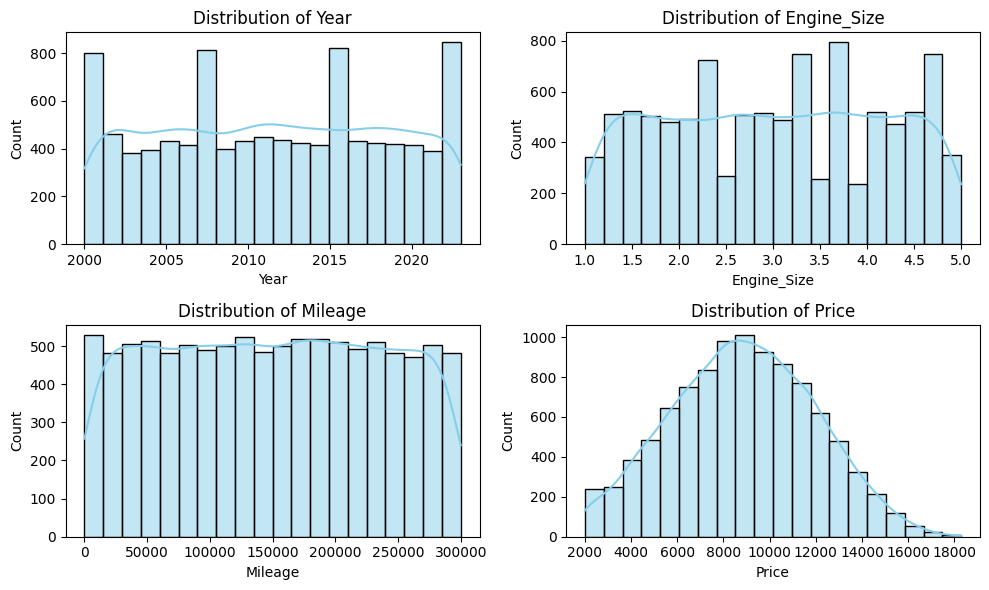

In [6]:
# Step 5: Data Visualization
# 5.1: Histograms for Numerical Features
# Histograms help us to understand the distribution of numerical features such as Year, Engine_Size, Mileage, and Price.

import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
numerical_features = ['Year', 'Engine_Size', 'Mileage', 'Price']

plt.figure(figsize=(10, 6))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True, color='skyblue', bins=20)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()

plt.show()


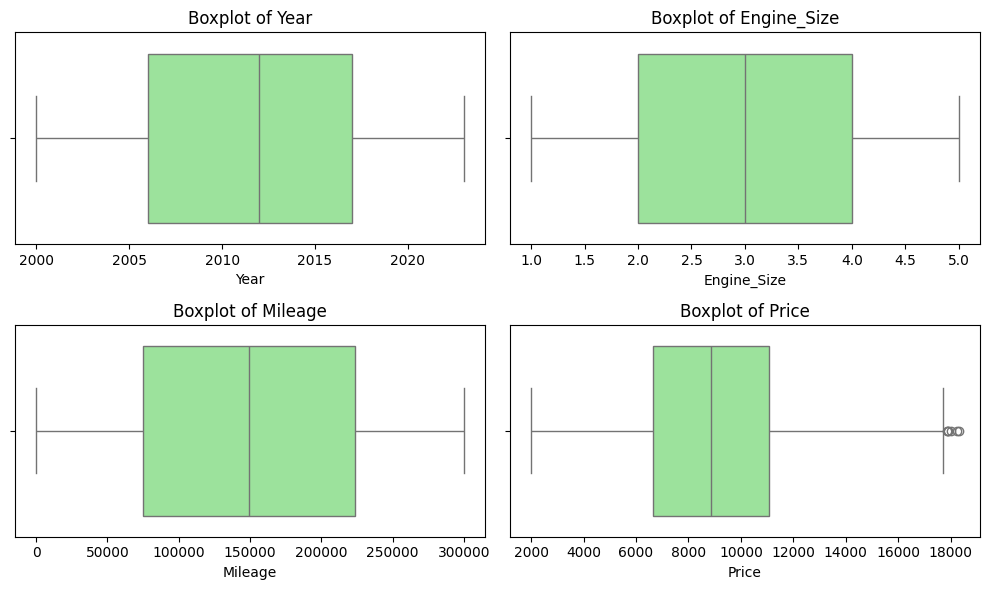

In [7]:
# 5.2: Boxplots for Outlier Detection
# Boxplots help us detect outliers in the numerical columns, which might need to be handled before training the model.

# Boxplots to detect outliers
plt.figure(figsize=(10, 6))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x=feature, color='lightgreen')
    plt.title(f'Boxplot of {feature}')
    plt.tight_layout()

plt.show()


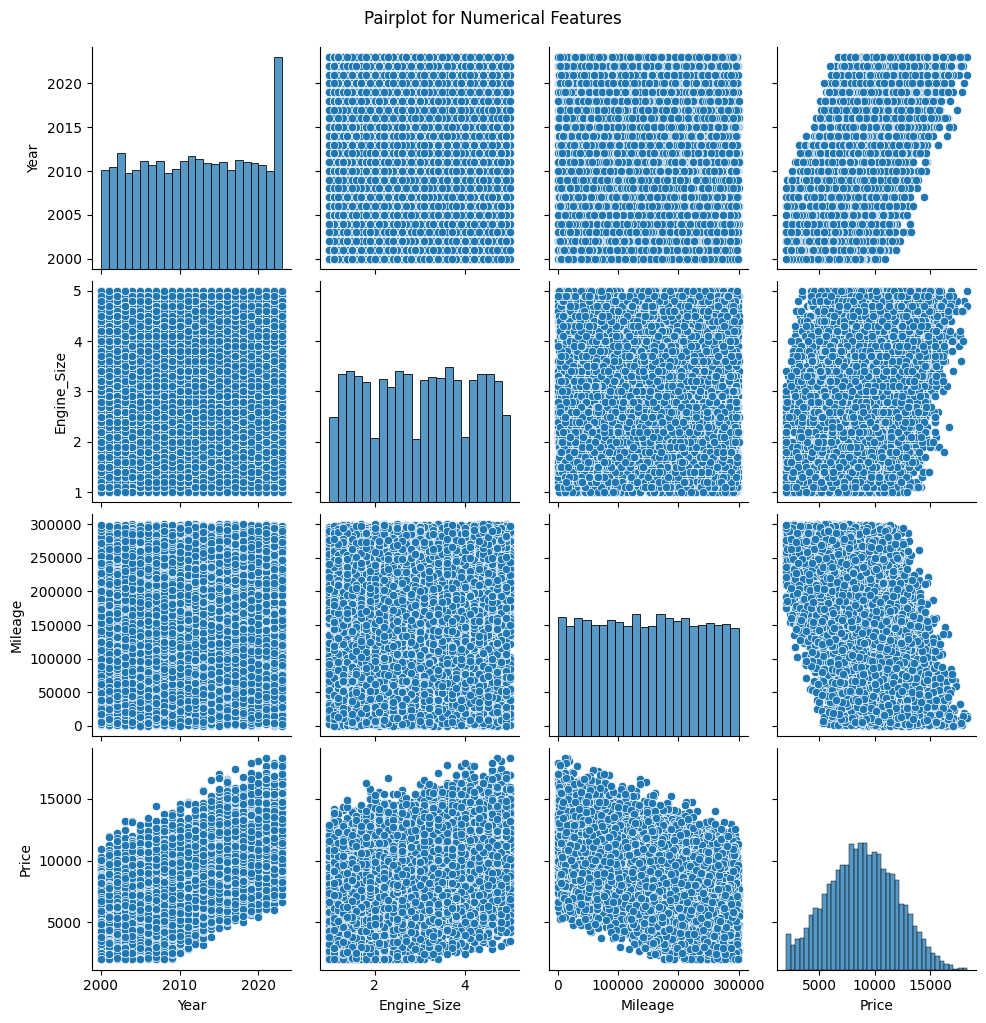

In [8]:
# 5.3: Pairplot for Relationships Between Features
# A pairplot is a great way to see pairwise relationships between features, especially if there are multiple numerical features.

# Pairplot to visualize relationships between numerical features
sns.pairplot(df[numerical_features], height=2.5)
plt.suptitle("Pairplot for Numerical Features", y=1.02)
plt.show()


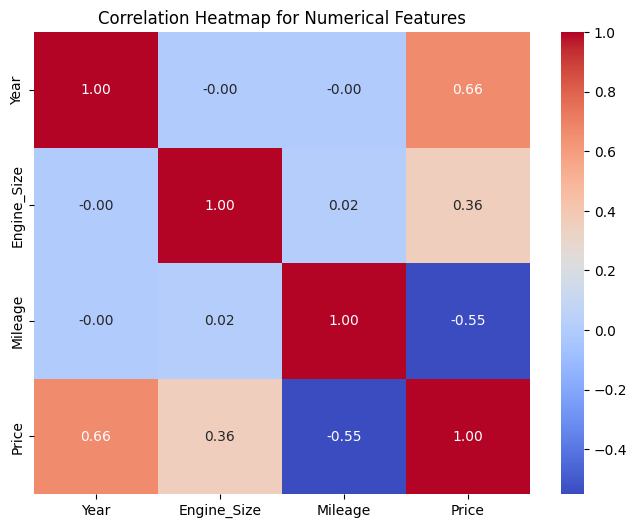

In [9]:
# 5.4: Correlation Heatmap
# A correlation heatmap can give us insights into how strongly the numerical features are correlated with each other. 
# This is helpful for identifying multicollinearity or feature importance.

# Correlation Heatmap
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Correlation Heatmap for Numerical Features")
plt.show()


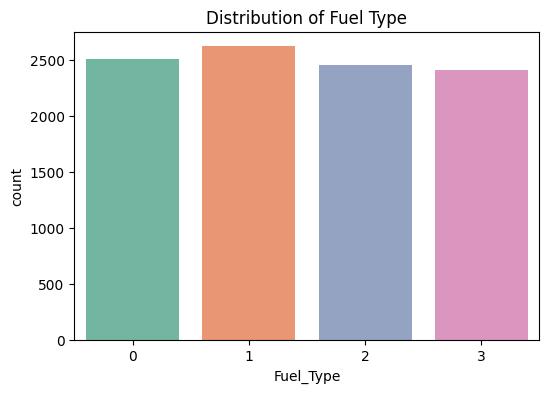

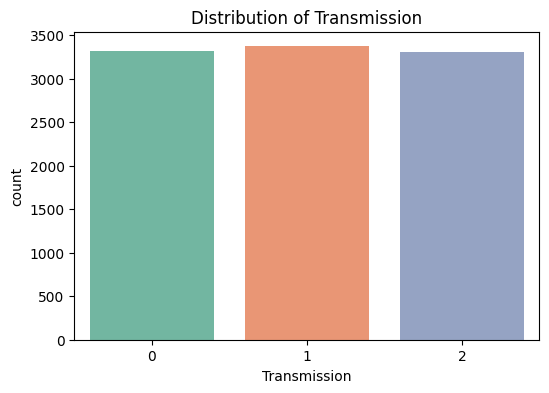

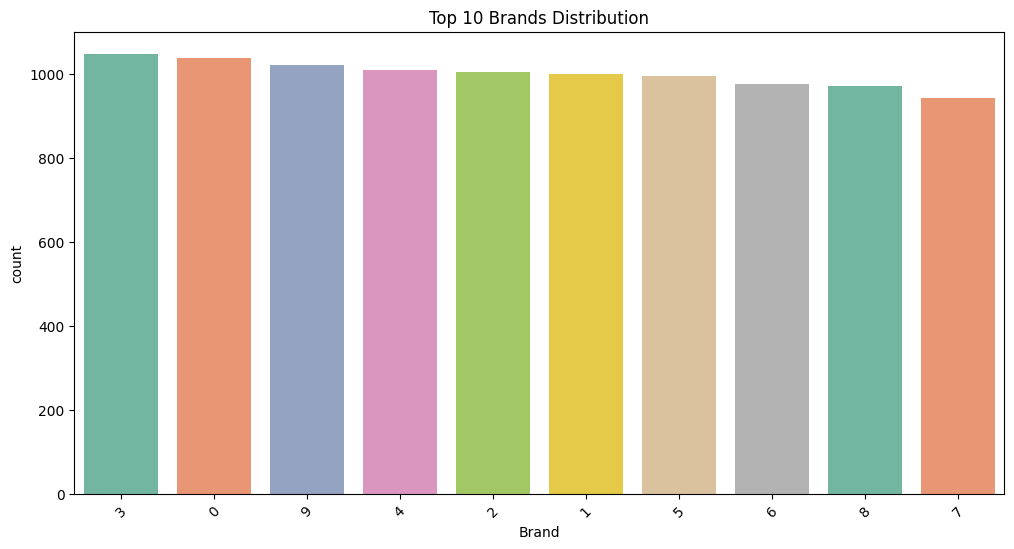

In [10]:
# 5.5: Bar and Count Plots for Categorical Data
# Bar and count plots are used to visualize the distribution of categorical features. For instance, Brand, Fuel_Type, 
# and Transmission are categorical features in this dataset.

# Bar plot for 'Fuel_Type'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Fuel_Type', palette='Set2')
plt.title('Distribution of Fuel Type')
plt.show()

# Bar plot for 'Transmission'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Transmission', palette='Set2')
plt.title('Distribution of Transmission')
plt.show()

# Bar plot for 'Brand' (if you want to show top 10 brands for better visualization)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Brand', order=df['Brand'].value_counts().iloc[:10].index, palette='Set2')
plt.title('Top 10 Brands Distribution')
plt.xticks(rotation=45)
plt.show()


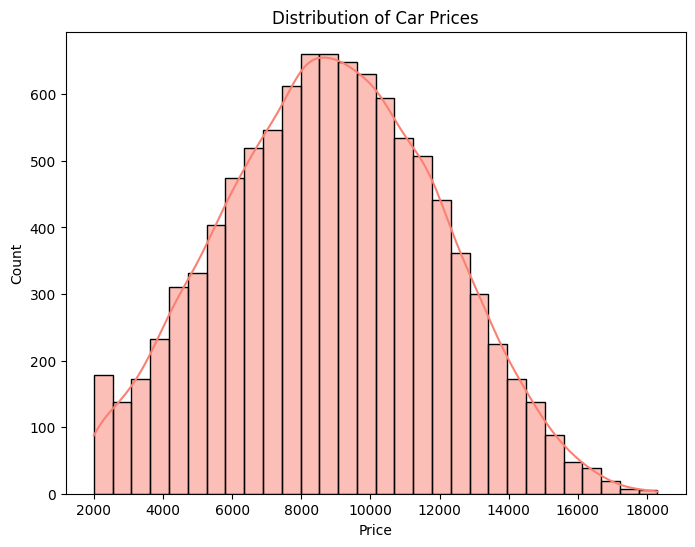

In [11]:
# 5.6: Data Distribution Check for Target Variable (Price)
# Since the target variable is Price, it is also important to check its distribution. 
# You can use a histogram or boxplot to visualize its distribution.

# Distribution of target variable 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(df['Price'], kde=True, color='salmon', bins=30)
plt.title('Distribution of Car Prices')
plt.show()


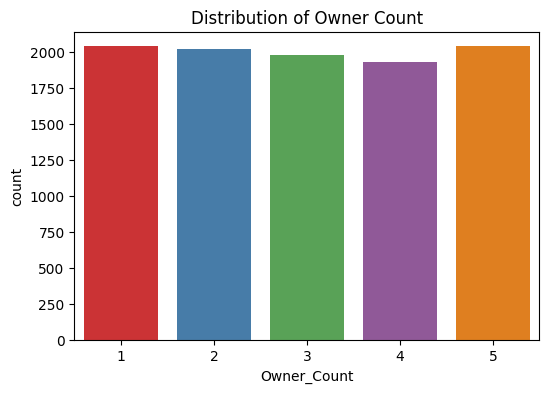

In [12]:
# 5.7: Categorical Variable Count Plot Example
# If your dataset has other categorical columns like Owner_Count, Parch, etc., you can visualize their distribution as well.

# Count plot for 'Owner_Count'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Owner_Count', palette='Set1')
plt.title('Distribution of Owner Count')
plt.show()


In [14]:
# Step 6: Model Training and Evaluation
# Now that the data is preprocessed, we can train a Random Forest Regressor and XGBoost Regressor to predict car prices.

# Train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate Random Forest
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_pred = rf_model.predict(X_test)
print(f"Random Forest R2: {r2_score(y_test, rf_pred)}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_pred)}")
print(f"Random Forest MSE: {mean_squared_error(y_test, rf_pred)}")

# Train XGBoost Regressor
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate XGBoost
xgb_pred = xgb_model.predict(X_test)
print(f"XGBoost R2: {r2_score(y_test, xgb_pred)}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, xgb_pred)}")
print(f"XGBoost MSE: {mean_squared_error(y_test, xgb_pred)}")



Random Forest R2: 0.9762020815778367
Random Forest MAE: 370.66837
Random Forest MSE: 218650.79685400004
XGBoost R2: 0.9960112571716309
XGBoost MAE: 151.04132080078125
XGBoost MSE: 36647.62109375


In [15]:
# Step 7: Save the Models Using Pickle
# Once the models are trained, you need to save them as .pkl files so that you can load them in the Streamlit app for predictions.

# Save Random Forest model
with open('random_forest_model_car.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save XGBoost model
with open('xgboost_model_car.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)


In [16]:
# Step 8: Streamlit App Development
# Now, we can create the Streamlit app (carapp.py) to allow the user to input car details and predict the price.
# Streamlit App (carapp.py):

import pickle
import streamlit as st
import numpy as np
import pandas as pd

# Load models
@st.cache_resource
def load_rf_model():
    with open('random_forest_model_car.pkl', 'rb') as f:
        return pickle.load(f)

@st.cache_resource
def load_xgb_model():
    with open('xgboost_model_car.pkl', 'rb') as f:
        return pickle.load(f)

# Streamlit app
st.title("Car Price Prediction App")

# Model selection
model_option = st.selectbox("Select Model", ["Random Forest", "XGBoost"])

# Input fields
brand = st.text_input("Brand")
model = st.text_input("Model")
year = st.number_input("Year", min_value=1900, max_value=2025, step=1)
engine_size = st.number_input("Engine Size (L)", min_value=0.0, step=0.1)
fuel_type = st.selectbox("Fuel Type", ["Petrol", "Diesel", "Electric"])
transmission = st.selectbox("Transmission", ["Manual", "Automatic"])
mileage = st.number_input("Mileage (km)", min_value=0, step=100)
doors = st.number_input("Doors", min_value=1, max_value=5, step=1)
owner_count = st.number_input("Owner Count", min_value=1, step=1)

# Prepare input data
input_data = pd.DataFrame([[brand, model, year, engine_size, fuel_type, transmission, mileage, doors, owner_count]],
                          columns=['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count'])

# Feature encoding
label_encoder = LabelEncoder()
input_data['Brand'] = label_encoder.fit_transform(input_data['Brand'])
input_data['Model'] = label_encoder.fit_transform(input_data['Model'])
input_data['Fuel_Type'] = label_encoder.fit_transform(input_data['Fuel_Type'])
input_data['Transmission'] = label_encoder.fit_transform(input_data['Transmission'])

# Prediction
if st.button("Predict Price"):
    if model_option == "Random Forest":
        model = load_rf_model()
    else:
        model = load_xgb_model()

    prediction = model.predict(input_data)

    st.write(f"The predicted car price is: ${prediction[0]:,.2f}")


2025-05-01 15:37:28.049 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 15:37:28.528 
  command:

    streamlit run C:\Users\gnikh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-05-01 15:37:28.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 15:37:28.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 15:37:28.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 15:37:28.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 15:37:28.534 Thread 'MainThread': missing ScriptRunContext! This w